# <font color='teal'> **Entrega 1**:  </font>

> **Curso**: Machine Learning (MLY0100)     
> **Fecha**: Octubre de 2024    
> **Profesor**: Jorge Anais     



---


Integrantes:
 - Sebastian Herrera
 - Leandro Palma
 - Camilo Garrido
 - Esteban Badilla


---

![Sonny and Mariel high fiving.](https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExb3F2eWhoZGc0a2k4M3BzN3B4a29lOG5jcDl0dTUycW12OWYzYTQ1NyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/KPozlPlz6dOww/giphy.gif)

In [1]:
import numpy as np # Programación vectorial
import matplotlib.pyplot as plt # Visualización
import pandas as pd # Estructura y manipulación de datos
from seaborn import heatmap, barplot
# from pandas_profiling import ProfileReport
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, roc_auc_score
# Encodeo
from sklearn import preprocessing, linear_model
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


In [2]:
url_data = 'https://drive.google.com/file/d/1kbBKQzc2Yde1uFWkCj4US_DjrL-0x0AO/view?usp=drive_link'
!gdown --fuzzy $url_data

Downloading...
From: https://drive.google.com/uc?id=1kbBKQzc2Yde1uFWkCj4US_DjrL-0x0AO
To: /content/Base_clientes_Monopoly-0.csv
100% 87.5M/87.5M [00:00<00:00, 91.6MB/s]


In [ ]:
data = pd.read_csv('Base_clientes_Monopoly-0.csv', sep=";")

<ipython-input-3-571c2b13619d>:1: DtypeWarning: Columns (5,19,20,32,38,54,60,61,78,84,100,107,124,130,146,152,153,192,198,199,238,244,245,284,291,308,314,330,337,376,382,383,422,429,446,452,468,474,475,514,521,560,567) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Base_clientes_Monopoly-0.csv', sep=";")


## <font color='teal'> 1. Parte I: Modelos de regresión </font>

Se crearán 5 modelos de regresion en base a 15 variables para precedir la variable renta y en base a sus metricas escojeremos el que mejor capture los datos.

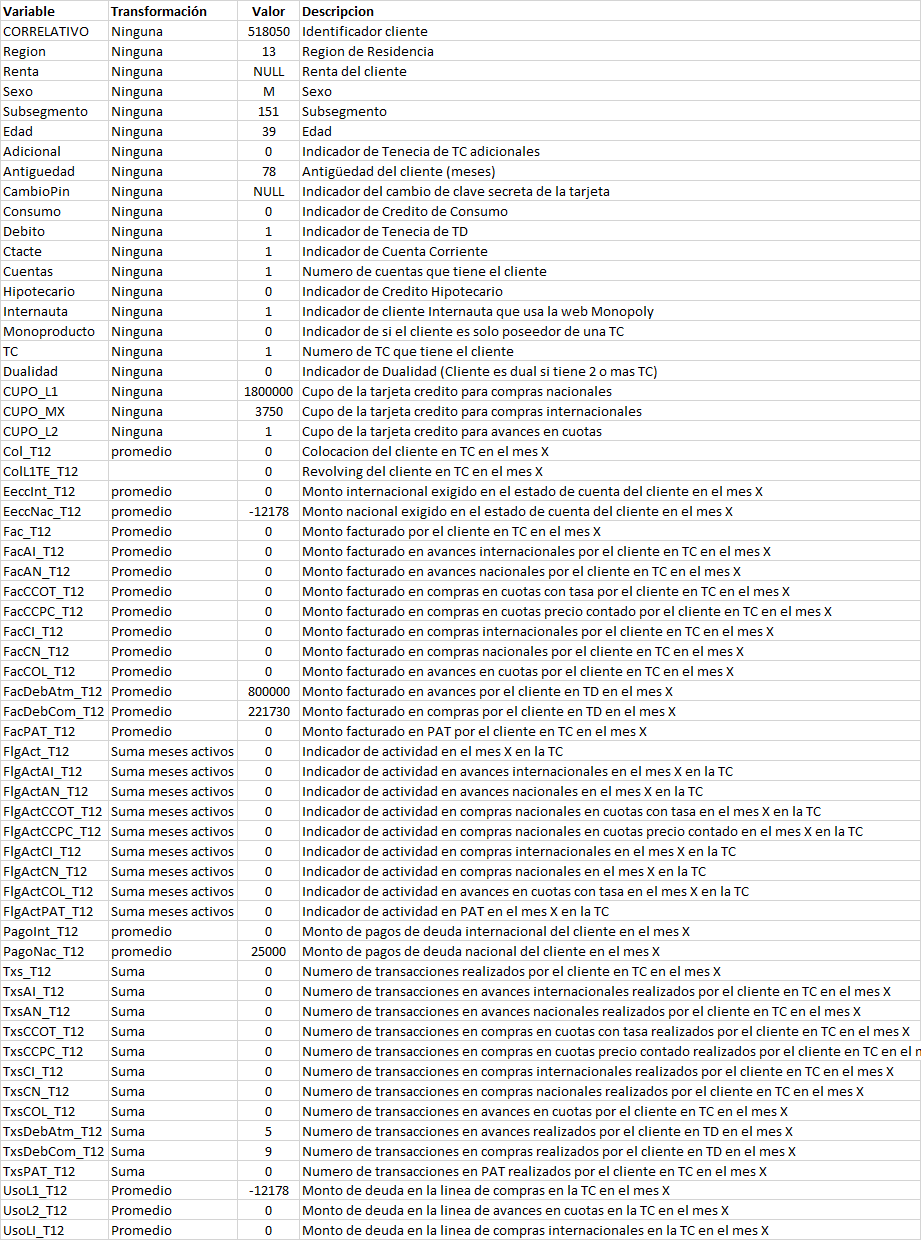

### 1.1 Selección de variables

In [ ]:
# Creamos un diccionario para almacenar los DataFrames por mes
data_por_mes = {}
listaSufijos = ["_T01", "_T02", "_T03", "_T04", "_T05", "_T06", "_T07", "_T08", "_T09", "_T10", "_T11", "_T12"]
# Iteramos sobre los meses (T1 a T12)
for mes in listaSufijos:
    # Creamos el sufijo del mes (T1, T2, ..., T12)
    sufijo_mes = mes
    # Seleccionamos las columnas que terminan con el sufijo correspondiente al mes
    columnas_mes = [col for col in data.columns if col.endswith(sufijo_mes)]
    # Creamos un DataFrame para el mes seleccionado, conservando también las columnas que no están relacionadas con meses
    columnas_sin_mes = [col for col in data.columns if not any(sufijo in col for sufijo in ["_T01", "_T02", "_T03", "_T04", "_T05", "_T06", "_T07", "_T08", "_T09", "_T10", "_T11", "_T12"])]
    # Concatenamos las columnas sin mes con las del mes correspondiente
    df_mes = data[columnas_sin_mes + columnas_mes]
    # Guardamos el DataFrame en el diccionario
    data_por_mes[f"df{mes}"] = df_mes

In [ ]:
data_por_mes['df_T06'].columns

Index(['Id', 'Subsegmento', 'Sexo', 'Region', 'Edad', 'Renta', 'Antiguedad',
       'Internauta', 'Adicional', 'Dualidad', 'Monoproducto', 'Ctacte',
       'Consumo', 'Hipotecario', 'Debito', 'CambioPin', 'Cuentas', 'TC',
       'CUPO_L1', 'CUPO_L2', 'CUPO_MX', 'target', 'FlgAct_T06', 'FlgActCN_T06',
       'FlgActCI_T06', 'FlgActAN_T06', 'FlgActAI_T06', 'FlgActPAT_T06',
       'FlgActCCPC_T06', 'FlgActCCOT_T06', 'FlgActCOL_T06', 'Fac_T06',
       'Txs_T06', 'FacCN_T06', 'TxsCN_T06', 'FacCI_T06', 'TxsCI_T06',
       'FacAN_T06', 'TxsAN_T06', 'FacAI_T06', 'TxsAI_T06', 'FacPAT_T06',
       'TxsPAT_T06', 'FacCCPC_T06', 'TxsCCPC_T06', 'FacCCOT_T06',
       'TxsCCOT_T06', 'FacCOL_T06', 'TxsCOL_T06', 'FacDebCom_T06',
       'TxsDebCom_T06', 'FacDebAtm_T06', 'TxsDebAtm_T06', 'Col_T06',
       'ColL1T0_T06', 'ColL1TE_T06', 'ColL2T0_T06', 'ColL2AC_T06',
       'ColL2CC_T06', 'ColMx_T06', 'PagoNac_T06', 'PagoInt_T06', 'EeccNac_T06',
       'EeccInt_T06', 'UsoL1_T06', 'UsoL2_T06', 'UsoLI_T06', 'I

In [ ]:
#A continuación crearemos un array que contenga las variables a utilizar
variables = ['Sexo', 'Edad', 'CUPO_L1', 'Fac_T06', 'Txs_T06', 'FacCN_T06', 'TxsCN_T06','CUPO_MX'
             ,'FacCCPC_T06', 'ColL1T0_T06','Col_T06', 'ColL2T0_T06']

**JUSTIFICACION**

Estamos buscando renta, asi que primero buscamos la correlacion que tienen todas las variables con renta, y al ver que ninguna tiene una buena correlacion con renta, asi que buscamos las que tenian una relacion entre si y esas son las que utilizamos para trabajar

### 1.2 Correlación entre las variables

In [ ]:
data_por_mes['df_T06'] = data_por_mes['df_T06'].apply(pd.to_numeric, errors='coerce')

In [ ]:
dataNumerica = data_por_mes['df_T06'].select_dtypes(include=['float64','int64'])
# Calcular la matriz de correlación en el DataFrame muestreado
correlation_matrix = dataNumerica.corr()

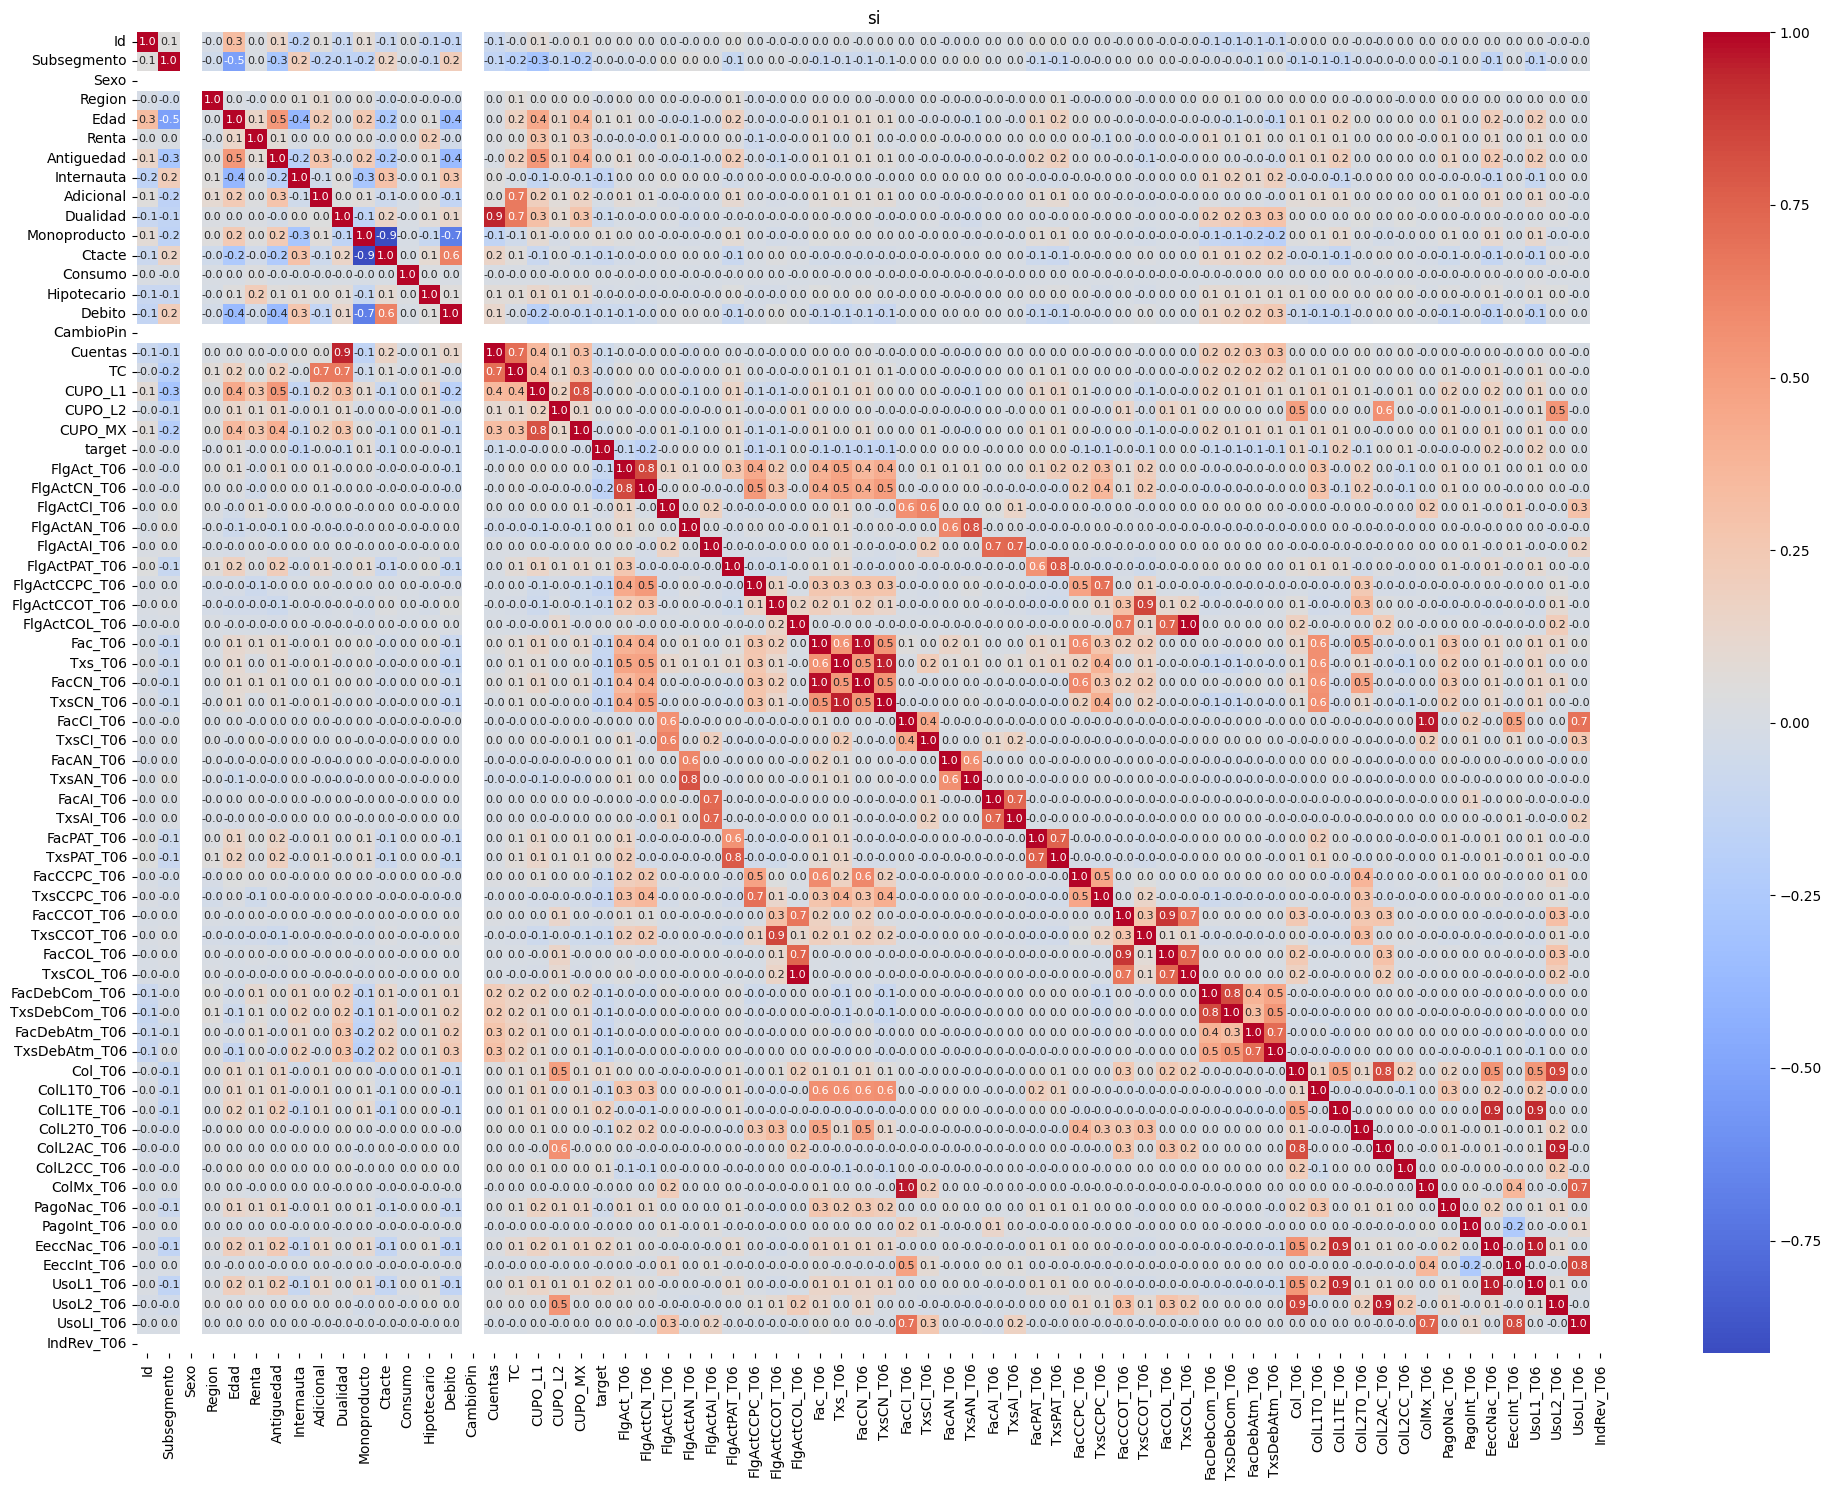

In [ ]:
plt.figure(figsize=(20, 15))
heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt= ".1f",annot_kws={'size':8})
plt.title('si')
plt.tight_layout()
# Mostrar el gráfico
plt.show()

### 1.3 Preparación de datos


Encoding

In [ ]:
le = preprocessing.LabelEncoder()
data_por_mes['df_T06']['Sexo'] = le.fit_transform(data_por_mes['df_T06']['Sexo'])

In [ ]:
le = preprocessing.LabelEncoder()
data_por_mes['df_T06']['IndRev_T06'] = le.fit_transform(data_por_mes['df_T06']['IndRev_T06'])

In [ ]:
data_por_mes['df_T06']['CambioPin'] = data_por_mes['df_T06']['CambioPin'].fillna(0)

In [ ]:
le = preprocessing.LabelEncoder()
data_por_mes['df_T06']['IndRev_T06'] = le.fit_transform(data_por_mes['df_T06']['IndRev_T06'])

In [ ]:
data_por_mes['df_T06']['CambioPin'] = data_por_mes['df_T06']['CambioPin'].fillna(0)

Escalamiento

In [ ]:
dataScaler = data_por_mes['df_T06'].drop(columns=['Sexo', 'IndRev_T06', 'Id',	'Subsegmento','Region',	'Edad',
                                                  'Renta',	'Antiguedad'	,'Internauta'	,'Adicional'	,'Dualidad',
                                                  'Monoproducto','Ctacte', 'Consumo', 'Hipotecario','Debito','CambioPin',
                                                  'Cuentas', 'TC','target'])

In [ ]:
scaler = StandardScaler()

scaler.fit(dataScaler)

array_scaler = scaler.transform(dataScaler)
array_scaler

array([[-0.31124832,  0.90184772, -0.11915276, ...,  3.01804351,
         0.08666864, -0.02039129],
       [-0.35582023, -0.23546465, -0.25062104, ...,  1.35325859,
        -0.16729463,         nan],
       [ 0.20132862, -0.16949525,  0.06239868, ..., -0.57977094,
        -0.31532469, -0.02039129],
       ...,
       [-0.06703141, -0.17648801,  0.0786757 , ..., -0.52976207,
        -0.28495573, -0.02039129],
       [ 0.44461695, -0.03755646,  0.56323022, ..., -0.44579154,
        -0.31532469, -0.02039129],
       [ 1.4878076 , -0.43337151,  1.13292611, ...,         nan,
        -0.31532469, -0.02039129]])

In [ ]:
df_scaler = pd.DataFrame(array_scaler)

In [ ]:
df_scaler.columns = dataScaler.columns


In [ ]:
dataSinScaler = data_por_mes['df_T06'][['Sexo', 'IndRev_T06', 'Id',	'Subsegmento','Region',	'Edad',
                                        'Renta',	'Antiguedad'	,'Internauta'	,'Adicional'	,'Dualidad',
                                        'Monoproducto','Ctacte', 'Consumo', 'Hipotecario','Debito','CambioPin',
                                        'Cuentas', 'TC','target']].copy()

In [ ]:
dataTratada = pd.concat([dataSinScaler, df_scaler], axis=1)

Calculo del porcentaje de valores nulos

In [ ]:
nulos = data_por_mes['df_T06']["Renta"].isnull().sum()

# Calcula el porcentaje de valores nulos por columna
porcentaje_nulos = (nulos / len(data_por_mes['df_T06']["Renta"])) * 100

# Itera sobre cada columna para mostrar su porcentaje de nulos
print(f"Porcentaje de nulos de renta: {porcentaje_nulos:.2f}%")

Porcentaje de nulos de renta: 26.15%


KNN

In [ ]:
datosKnn = dataTratada.copy()

In [ ]:
knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")

In [ ]:
datosKnn['Renta'] = knn_imputer.fit_transform(datosKnn[['Renta']])

In [ ]:
dataTratada['Renta'] = datosKnn['Renta']

In [ ]:
dataSinNulos = dataTratada.dropna()

### 1.4 Ajuste modelos de regresión

Antes de comenzar con los modelos realizaremos la separacion entre datos de train y test

In [ ]:
#x = dataSinNulos.drop(columns=['Renta'])
x = dataSinNulos[variables]
y = dataSinNulos['Renta']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Regresion lineal

In [ ]:
linealModel = LinearRegression()
linealModel.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = linealModel.predict(x_test)

Metricas

In [ ]:
#Error Cuadratico Medio
mse = mean_squared_error(y_test, y_pred)

#Raiz Error Cuadratico Medio
rmse = np.sqrt(mse)

# Error Absoluto Medio (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Coeficiente de Determinación (R^2)
r2 = r2_score(y_test, y_pred)

# Imprimir las métricas
print(f'Error Cuadratico Medio (MSE): {mse}')
print(f'Raiz Error Cuadratico Medio: {rmse}')
print(f'Error Absoluto Medio (MAE): {mae}')
print(f'R^2: {r2}')

Error Cuadratico Medio (MSE): 105213705916.07428
Raiz Error Cuadratico Medio: 324366.6226911676
Error Absoluto Medio (MAE): 207781.2944683383
R^2: 0.07530180134938202


**INTERPRETACION**

Error cuadratico medio:El valor es bastante alto, lo que indica que el modelo está haciendo predicciones con errores significativos.

Raiz error cuadratico medio:Un RMSE de aproximadamente 324367 sugiere que, en promedio, las predicciones del modelo se desvían de los valores reales en esa cantidad.

Error absoluto medio:Un MAE de aproximadamente 207781 indica que en promedio las predicciones del modelo están desviadas de los valores reales por esa cantidad.

R²: Un R² de 0.075 sugiere que el modelo explica solo el 7.5% de la variabilidad de los datos. Esto significa que el modelo tiene un bajo poder predictivo y está lejos de ser adecuado para representar bien los datos.

**Overfitting/Underfitting**

**Interpretación:** La Regresión Lineal tiende a ser un modelo muy simple que puede no captar relaciones complejas entre las variables. Dado que su rendimiento en términos de MSE y R² es bajo, es probable que esté sufriendo de underfitting. Esto significa que no está ajustándose adecuadamente a los datos, ya que las relaciones subyacentes son probablemente no lineales o más complejas.

#### Regresion Polinomial

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias = True)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

In [ ]:
reg_poly = linear_model.Lasso(alpha=0.1)
reg_poly.fit(x_train_poly, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.890e+15, tolerance: 4.090e+11
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.1)

In [ ]:
y_train_pred = reg_poly.predict(x_train_poly)
y_test_pred = reg_poly.predict(x_test_poly)

In [ ]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f'MSE Train: {mse_train}')
print(f'MSE Test: {mse_test}')
print(f'R^2: {r2}')

MSE Train: 107696171771.79762
MSE Test: 104955559592.64136
R^2: 0.07757058789376159


**INTERPRETACION**

MSE train:Un MSE de aproximadamente 107.7 mil millones indica que, en promedio, las predicciones del modelo tienen un error considerable cuando se evalúan en el conjunto de entrenamiento.

MSE test:Un MSE de aproximadamente 104.9 mil millones es similar al error en el conjunto de entrenamiento, lo que indica que el modelo no está sobreajustando los datos, ya que los errores en entrenamiento y prueba son comparables.

R²:Un R² de 0.077 sugiere que el modelo solo explica aproximadamente el 7.7% de la variabilidad de los datos.

**Overfitting/Underfitting**

Interpretación: La Regresión Polinomial, aunque puede captar ciertas relaciones no lineales, en este caso específico tiene un MSE elevado y un R² bajo. Esto indica que también está sufriendo de underfitting. A pesar de ser un modelo más flexible que la regresión lineal, parece que no está logrando capturar las complejidades de los datos, tal vez debido a un grado de polinomio que no es adecuado.

#### RandomForrest Regressor

In [ ]:
RandomForestModel = RandomForestRegressor(n_estimators=100, random_state=42)
RandomForestModel.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = RandomForestModel.predict(x_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Error Cuadratico Medio (MSE): {mse}')
print(f'R^2: {r2}')

Error Cuadratico Medio (MSE): 107331792309.48396
R^2: 0.05668644458080074


**INTERPRETACION**

Error cuadratico medio:Un MSE de aproximadamente 107.3 mil millones indica que el modelo está cometiendo errores importantes en sus predicciones.

R²:Un R² de 0.056 sugiere que el modelo de Random Forest solo es capaz de explicar aproximadamente el 5.7% de la variabilidad en los datos.

**Overfitting/Underfitting**

Interpretación: El Random Forest es un modelo más complejo que generalmente tiende a evitar el underfitting. Sin embargo, si el MSE es considerablemente alto y el R² es bajo, podría ser una señal de que, a pesar de su complejidad, está sufriendo de underfitting si no se ha ajustado adecuadamente a los datos, posiblemente por falta de profundidad en los árboles o por un número insuficiente de árboles en el modelo.

#### Support Vector Regression (*SVR*)

In [ ]:
svr_model = SVR(kernel='rbf', C=50, gamma='scale')
svr_model.fit(x_train, y_train)

SVR(C=50)

In [ ]:
y_pred = svr_model.predict(x_test)

In [ ]:
# Evaluar el error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Error cuadrático medio: {mse}')
print(f'R^2: {r2}')

Error cuadrático medio: 113798621901.70045
R^2: -0.00014898026083587368


**INTERPRETACION**

Error cuadratico medio:Un MSE de aproximadamente 113.8 mil millones indica que el modelo está cometiendo errores significativos en sus predicciones. Este valor es bastante elevado y sugiere que el modelo no se ajusta bien a los datos, produciendo predicciones que están lejos de los valores reales.

R²:Un R² negativo sugiere que el modelo de SVR es incapaz de explicar la variabilidad de los datos y, de hecho, está haciendo un trabajo peor que simplemente utilizar la media de los valores reales como predicción.

**Overfitting/Underfitting**

Interpretación: Dado que el SVR se basa en principios de margen, puede ser más robusto en comparación con modelos más simples. Sin embargo, si el MSE es alto y el R² es bajo, indicaría que el SVR no está capturando bien las variaciones en los datos, lo que sugiere que también está sufriendo de underfitting. Esto podría deberse a una elección inapropiada de hiperparámetros.

#### Arbol de decisión

In [ ]:
tree = DecisionTreeRegressor(criterion='squared_error',
                               max_depth=5,
                               min_samples_split=10,
                               min_samples_leaf=5,
                               max_features='sqrt',
                               random_state=42)
tree.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=10, random_state=42)

In [ ]:
y_pred = tree.predict(x_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Error cuadrático medio: {mse}')
print(f'R^2: {r2}')

Error cuadrático medio: 105347673892.47968
R^2: 0.07412438871687055


**INTERPRETACION**

Error cuadratico medio:Un MSE de aproximadamente 105.3 mil millones indica que el modelo está cometiendo errores significativos en sus predicciones.

R²:Un R² de aproximadamente 0.074 sugiere que el modelo de Árbol de Decisión solo es capaz de explicar alrededor del 7.4% de la variabilidad en los datos.

**Overfitting/Underfitting**

Interpretación: Un Árbol de Decisión, dependiendo de cómo se configure (profundidad, número mínimo de muestras por hoja, etc.), puede ser propenso tanto al overfitting como al underfitting. Si se encuentra que tiene un rendimiento razonable pero no excelente (por ejemplo, un R² bajo), esto indicaría que podría estar sufriendo de underfitting. Si por el contrario, el rendimiento en los datos de entrenamiento es significativamente mejor que en los de prueba, indicaría overfitting. Basado en la información proporcionada, el modelo parece tener un desempeño aceptable, pero con margen de mejora, sugiriendo que podría estar en el límite de underfitting.

### 1.5 Evaluación de los modelos

| Modelo   | MSE | RMSE | R^2 | MAE |
|----------|-----------|-----------|-----|-----|
| Lineal     | 105213705916.07428      | 324366.6227      | 0.0753    | 207781.2945    |
| Polinomial | 107696171771.79762      |  ---     |0.0776     | ---    |
| Random Forest| 107331792309.48396      |  ---     |0.0567     |  ---   |
| SVR | 113798621901.70045       |  ---     | -0.0001    | ---   |
| Arbol de Decision | 105347673892.47968   |  ---     | 0.0741    | ---    |

**Mejor Modelo: Modelo Polinomial**

Aunque todos los modelos presentan un rendimiento bajo, el modelo polinomial tiene el menor MSE en el conjunto de prueba y el mejor R² entre los modelos evaluados, aunque aún es insuficiente para evaluar bien los datos de renta.


---



**Peor Modelo: SVR (Support Vector Regression)**

Con el MSE más alto y un R² negativo, el SVR es el modelo que peor rendimiento tiene, indicando que no captura la variabilidad de los datos en absoluto.

## <font color='teal'>2. Parte II: Modelos de clasificación</font>

### 2.1 Selección de variables

In [ ]:
data_por_mes['df_T06'].columns

Index(['Id', 'Subsegmento', 'Sexo', 'Region', 'Edad', 'Renta', 'Antiguedad',
       'Internauta', 'Adicional', 'Dualidad', 'Monoproducto', 'Ctacte',
       'Consumo', 'Hipotecario', 'Debito', 'CambioPin', 'Cuentas', 'TC',
       'CUPO_L1', 'CUPO_L2', 'CUPO_MX', 'target', 'FlgAct_T06', 'FlgActCN_T06',
       'FlgActCI_T06', 'FlgActAN_T06', 'FlgActAI_T06', 'FlgActPAT_T06',
       'FlgActCCPC_T06', 'FlgActCCOT_T06', 'FlgActCOL_T06', 'Fac_T06',
       'Txs_T06', 'FacCN_T06', 'TxsCN_T06', 'FacCI_T06', 'TxsCI_T06',
       'FacAN_T06', 'TxsAN_T06', 'FacAI_T06', 'TxsAI_T06', 'FacPAT_T06',
       'TxsPAT_T06', 'FacCCPC_T06', 'TxsCCPC_T06', 'FacCCOT_T06',
       'TxsCCOT_T06', 'FacCOL_T06', 'TxsCOL_T06', 'FacDebCom_T06',
       'TxsDebCom_T06', 'FacDebAtm_T06', 'TxsDebAtm_T06', 'Col_T06',
       'ColL1T0_T06', 'ColL1TE_T06', 'ColL2T0_T06', 'ColL2AC_T06',
       'ColL2CC_T06', 'ColMx_T06', 'PagoNac_T06', 'PagoInt_T06', 'EeccNac_T06',
       'EeccInt_T06', 'UsoL1_T06', 'UsoL2_T06', 'UsoLI_T06', 'I

In [ ]:
variables = ['Sexo', 'Edad', 'CUPO_L1', 'Fac_T06', 'Txs_T06', 'FacCN_T06', 'TxsCN_T06','CUPO_MX'
             ,'FacCCPC_T06', 'ColL1T0_T06','Col_T06', 'ColL2T0_T06']
#Cambiar

**JUSTIFICACION**

Estamos buscando target, asi que primero buscamos la correlacion que tienen todas las variables con target, y al ver que ninguna tiene una buena correlacion con target, asi que buscamos las que tenian una relacion entre si y esas son las que utilizamos para trabajar

### 2.2 Correlación entre las variables seleccionadas

In [ ]:
correlation_matrix = dataTratada[variables].corr()

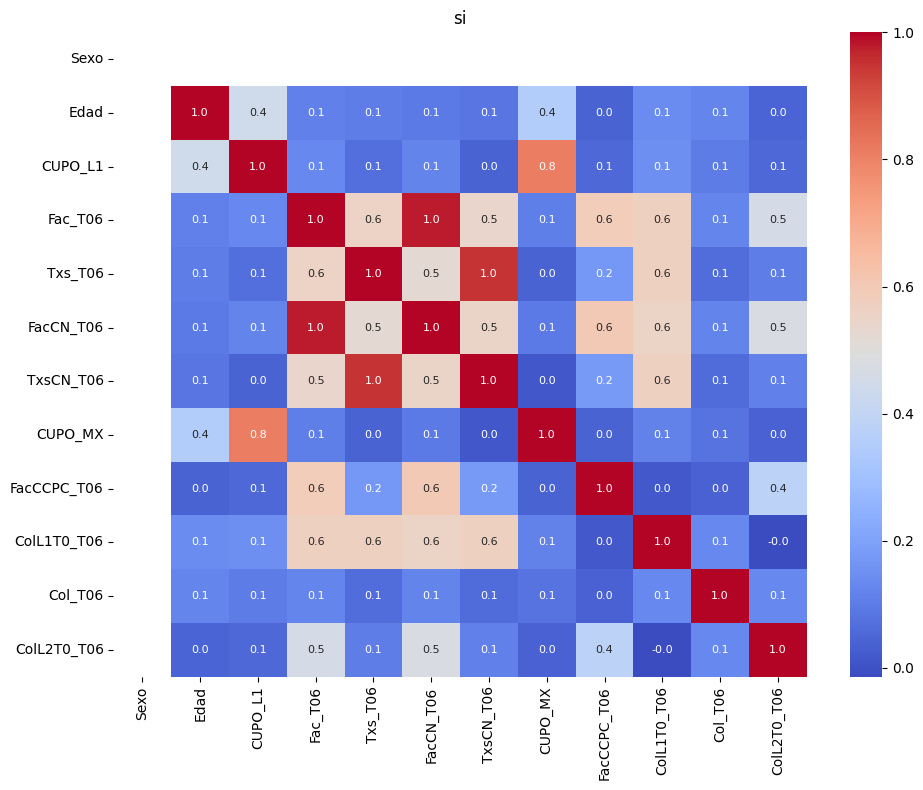

In [ ]:
plt.figure(figsize=(10, 8))
heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt= ".1f",annot_kws={'size':8})
plt.title('si')
plt.tight_layout()
# Mostrar el gráfico
plt.show()

### 2.3 Preparación de datos

Balance de clases

Veremos un grafico para ver el estado de la clase

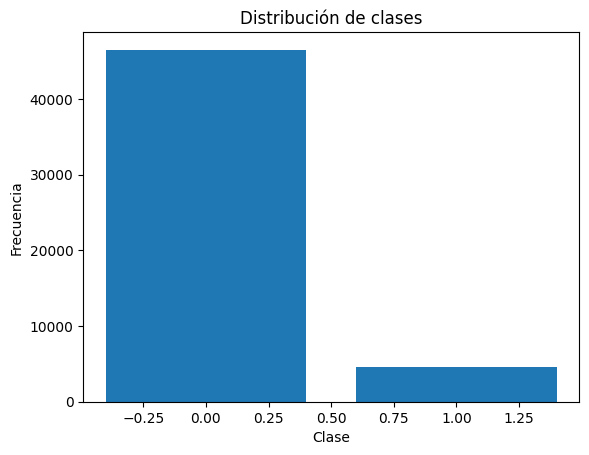

In [ ]:
clases = df_mes['target'].value_counts()
plt.bar(clases.index, clases.values)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de clases')
plt.show()

Para corregir el desbalance de clases usaremos SMOTE

In [ ]:
x = dataSinNulos[variables]
y = dataSinNulos['target']

smote = SMOTE(random_state=42)
x_smote, y_smote = smote.fit_resample(x, y)

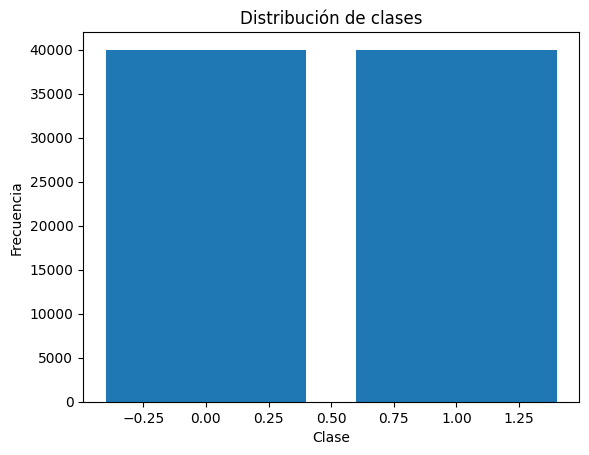

In [ ]:
clases = y_smote.value_counts()
plt.bar(clases.index, clases.values)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de clases')
plt.show()

In [ ]:

x_train, x_test, y_train, y_test = train_test_split(x_smote, y_smote, test_size=0.2, random_state=42)

### 2.4 Entrenamiento de modelos de clasificación

#### RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(n_estimators=100,
                             random_state=42,
                             )
rfc.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rfc.predict(x_test)

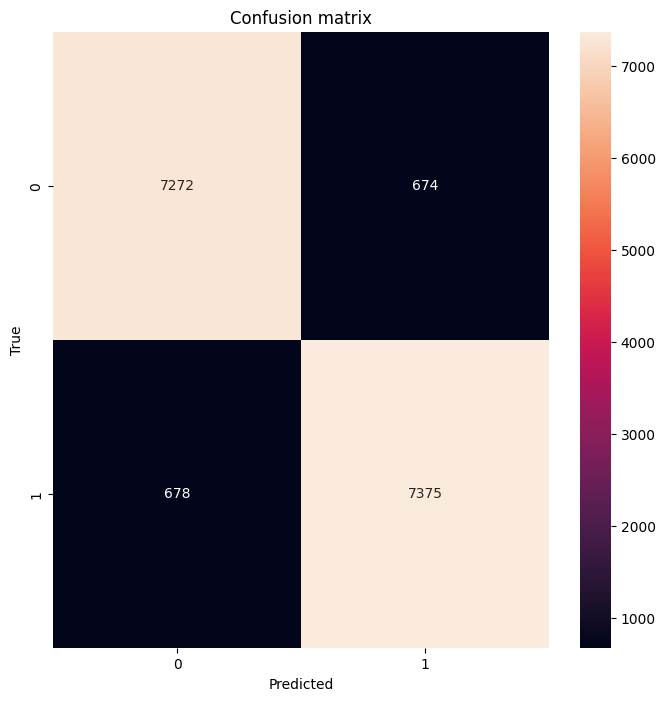

In [ ]:
LABELS = ["0","1"]

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",);
plt.title("Confusion matrix")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      7946
           1       0.92      0.92      0.92      8053

    accuracy                           0.92     15999
   macro avg       0.92      0.92      0.92     15999
weighted avg       0.92      0.92      0.92     15999



**INTERPRETACION**

**Precision**

La precisión mide la proporción de verdaderos positivos respecto a todos los positivos predichos. Un valor de 0.91 indica que el modelo está correcto el 91% de las veces al predecir tanto la clase 0 como la clase 1. Esto sugiere que el modelo tiene un buen desempeño en evitar falsos positivos.

**Recall**

El recall mide la proporción de verdaderos positivos respecto a todos los reales positivos. Un recall de 0.91 para la clase 0 y 0.92 para la clase 1 indica que el modelo es eficaz en identificar la mayoría de las instancias de ambas clases. Esto implica que hay pocos falsos negativos.

**F1-Score**

El F1-score es la media armónica entre la precisión y el recall. Un valor de 0.91 indica un balance sólido entre precisión y recall, lo que significa que el modelo está bien ajustado para ambas clases y no favorece excesivamente a una sobre la otra.

**Accuracy**

La precisión global indica que el modelo acertó en el 91% de las predicciones realizadas. Este es un buen nivel de exactitud y sugiere que el modelo tiene un rendimiento confiable.

**Overfitting/Underfitting**

Interpretación: Con una precisión del 91% y un buen equilibrio entre precisión y recall, el Random Forest Classifier muestra un rendimiento robusto. Es menos probable que esté sufriendo de underfitting. Sin embargo, si el rendimiento en el conjunto de entrenamiento es significativamente mejor que en el conjunto de prueba, podría indicar overfitting. Pero, basándose en los resultados presentados, el modelo parece estar bien ajustado.

Curva ROC

In [ ]:
y_prob = rfc.predict_proba(x_test)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc}")

AUC-ROC: 0.9729750539849435


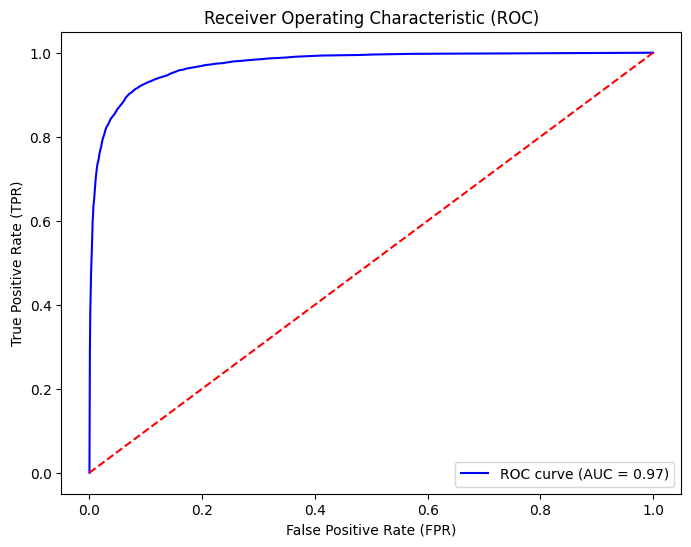

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de clasificación aleatoria
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

**INTERPRETACION**

Un AUC-ROC de 0.9729 indica que el modelo es altamente efectivo para la clasificación en el conjunto de datos evaluado, mostrando un balance notable entre sensibilidad y especificidad. Esto sugiere que el modelo es una buena opción para aplicaciones donde la clasificación correcta es crítica.

#### Regresion Logistica

In [ ]:
rlModel = LogisticRegression()
rlModel.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred = rlModel.predict(x_test)

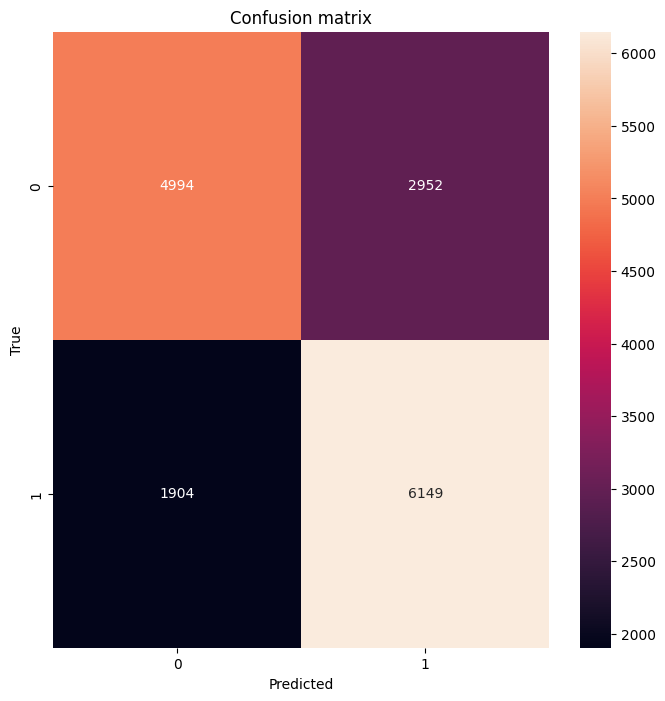

              precision    recall  f1-score   support

           0       0.72      0.63      0.67      7946
           1       0.68      0.76      0.72      8053

    accuracy                           0.70     15999
   macro avg       0.70      0.70      0.69     15999
weighted avg       0.70      0.70      0.70     15999



In [ ]:
LABELS = ["0","1"]

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",);
plt.title("Confusion matrix")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred))

**INTERPRETACION**

**Precision**

La precisión mide la proporción de verdaderos positivos respecto a todos los positivos predichos. Un valor de 0.72 para la clase 0 sugiere que el modelo está correcto el 72% de las veces al predecir esta clase. Para la clase 1, con 0.68, el modelo es correcto el 68% del tiempo al predecir esta clase. En general, la precisión es aceptable, pero hay margen de mejora, especialmente en la clase 1.

**Recall**

El recall mide la proporción de verdaderos positivos respecto a todos los reales positivos. Un recall de 0.63 para la clase 0 indica que el modelo identifica correctamente el 63% de las instancias de esta clase, lo que sugiere un número considerable de falsos negativos. Para la clase 1, el recall de 0.76 sugiere que el modelo es más eficaz en la identificación de instancias de esta clase. Esto indica que el modelo tiene un desempeño desigual entre las clases.

**F1-Score**

El F1-score es la media armónica entre la precisión y el recall. Con un F1-score de 0.67 para la clase 0 y 0.72 para la clase 1, el modelo muestra un mejor equilibrio para la clase 1, pero un rendimiento inferior para la clase 0. Esto indica que, si bien el modelo es razonablemente efectivo, podría beneficiarse de ajustes para mejorar su capacidad para identificar instancias de la clase 0.

**Accuracy**

La precisión global de 0.70 indica que el modelo acertó en el 70% de las predicciones realizadas. Este es un nivel de exactitud moderado, lo que sugiere que hay espacio para mejorar, especialmente en la identificación de instancias de la clase 0.

**Overfitting/Underfitting**

Interpretación: La Regresión Logística sin hiperparámetros muestra un rendimiento modesto, con una precisión de 72% en la clase 0 y 68% en la clase 1. Este rendimiento sugiere que el modelo no se está ajustando adecuadamente a los datos, lo que indica que podría estar sufriendo de underfitting. Las relaciones subyacentes pueden ser más complejas de lo que la Regresión Logística puede captar sin optimización.

Curva ROC

In [ ]:
y_prob = rlModel.predict_proba(x_test)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc}")

AUC-ROC: 0.7625672969684323


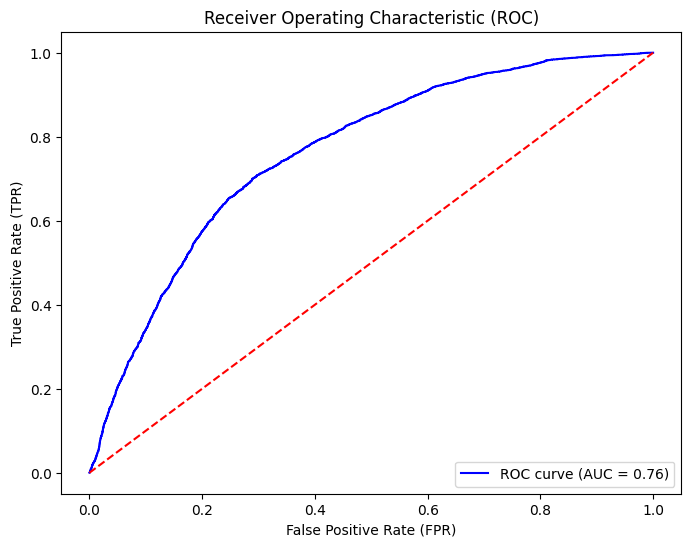

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de clasificación aleatoria
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

**INTERPRETACION**

Un AUC-ROC de 0.7626 sugiere que el modelo tiene una capacidad razonable para clasificar las instancias, pero hay espacio para mejoras. Este rendimiento puede ser adecuado para ciertos contextos, pero para aplicaciones críticas, se deberían explorar opciones para optimizar el modelo y aumentar su capacidad de discriminación.

#### Arbol de Decision sin Hyperparametros



In [ ]:
dtc_model = DecisionTreeClassifier()
dtc_model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dtc_model.predict(x_test)

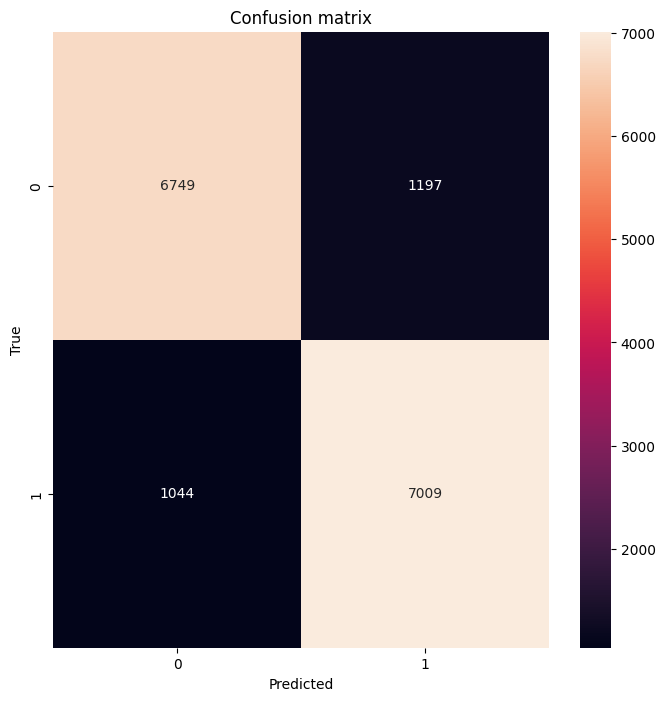

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      7946
           1       0.85      0.87      0.86      8053

    accuracy                           0.86     15999
   macro avg       0.86      0.86      0.86     15999
weighted avg       0.86      0.86      0.86     15999



In [ ]:
LABELS = ["0","1"]

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",);
plt.title("Confusion matrix")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred))

**INTERPRETACION**

**Precision**

La precisión mide la proporción de verdaderos positivos respecto a todos los positivos predichos. Un valor de 0.86 para ambas clases indica que el modelo tiene un buen desempeño en la clasificación, acertando el 86% de las veces en las predicciones de cada clase. Esto sugiere que el modelo es confiable al identificar las instancias de ambas clases.

**Recall**

Interpretación: El recall mide la proporción de verdaderos positivos respecto a todos los reales positivos. Un recall de 0.85 para la clase 0 y 0.87 para la clase 1 indica que el modelo es eficaz en la identificación de instancias de ambas clases, logrando captar el 85% y 87% de las instancias reales de cada clase, respectivamente. Esto sugiere que el modelo tiene un buen equilibrio en su capacidad para identificar correctamente las instancias.

**F1-Score**

El F1-score es la media armónica entre la precisión y el recall. Con un F1-score de 0.86 para ambas clases, el modelo demuestra un buen equilibrio entre precisión y recall. Esto indica que el árbol de decisión está funcionando bien y que los errores son relativamente bajos.

**Accuracy**

La precisión global de 0.86 indica que el modelo acertó en el 86% de las predicciones realizadas. Este es un nivel de exactitud elevado, lo que sugiere que el modelo es muy efectivo en general para clasificar las instancias.

**Overfitting/Underfitting**

Interpretación: El Árbol de Decisión sin hiperparámetros presenta una precisión del 86% y un rendimiento aceptable. Esto sugiere que el modelo está ajustándose razonablemente a los datos, pero si se encuentra que el rendimiento en el conjunto de entrenamiento es mucho mejor que en el de prueba, podría indicar overfitting. Si las métricas son similares en ambos conjuntos, se puede concluir que está adecuadamente ajustado, aunque es posible que aún haya margen de mejora.

Curva ROC

In [ ]:
y_prob = dtc_model.predict_proba(x_test)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc}")

AUC-ROC: 0.7823258300494687


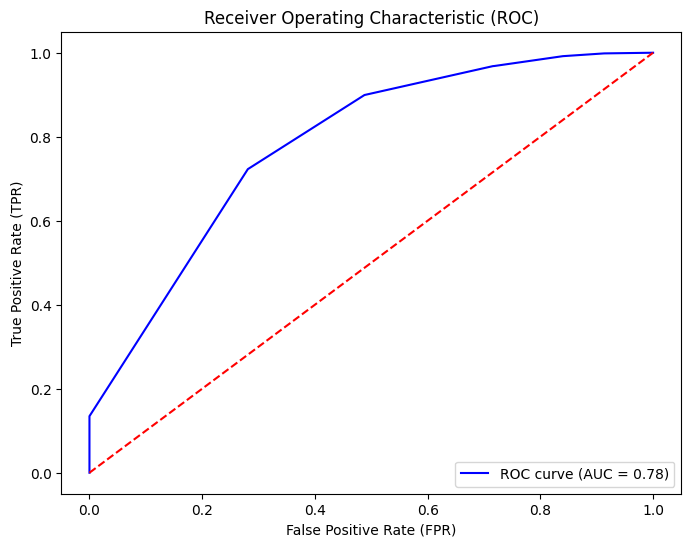

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de clasificación aleatoria
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

**INTERPRETACION**

Un AUC-ROC de 0.7823 sugiere que el modelo tiene una capacidad aceptable para clasificar las instancias y que puede ser efectivo en su tarea. Sin embargo, hay oportunidades para optimizar el modelo y aumentar su rendimiento, especialmente si se busca un modelo más robusto para aplicaciones críticas. Sería recomendable analizar otras métricas complementarias, como la precisión, el recall y el F1-score, para tener una visión más completa del rendimiento del modelo.

#### Arbol de decision con hyperparametros

In [ ]:
dtc_model = DecisionTreeClassifier(max_depth= 3,
                                  min_samples_split = 10,
                                  min_samples_leaf = 5,
                                  criterion = 'entropy' )
dtc_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       min_samples_split=10)

In [ ]:
y_pred = dtc_model.predict(x_test)

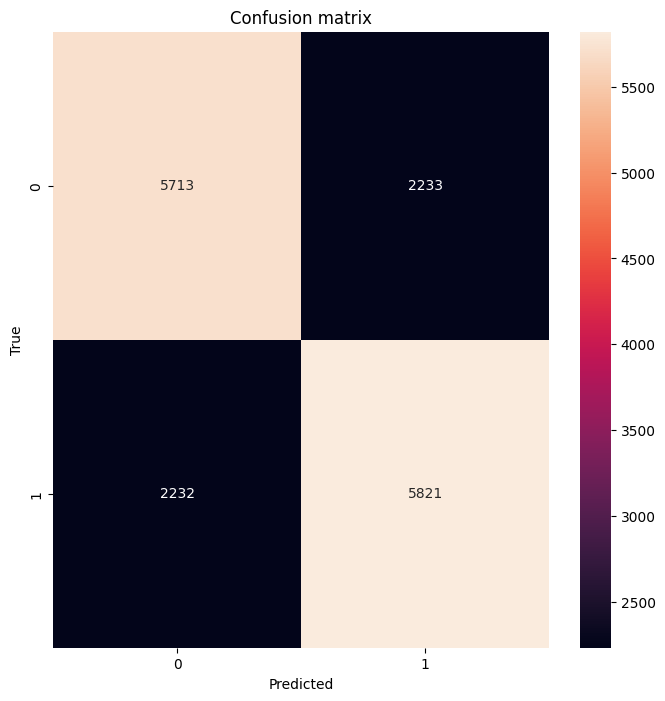

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      7946
           1       0.72      0.72      0.72      8053

    accuracy                           0.72     15999
   macro avg       0.72      0.72      0.72     15999
weighted avg       0.72      0.72      0.72     15999



In [ ]:
LABELS = ["0","1"]

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",);
plt.title("Confusion matrix")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred))

**INTERPRETACION**

**Precision**

La precisión mide la proporción de verdaderos positivos respecto a todos los positivos predichos. En este caso, una precisión de 0.72 indica que el modelo identifica correctamente el 72% de las instancias predichas como clase 0 y clase 1. Aunque es una precisión aceptable, no es tan alta como en el modelo de árbol de decisión sin hiperparámetros (que era de 0.86). Esto podría indicar que los ajustes en los hiperparámetros no mejoraron la capacidad del modelo para hacer predicciones más precisas.

**Recall**

El recall mide la proporción de verdaderos positivos con respecto a todos los positivos reales. Con un valor de 0.72, el modelo está identificando correctamente el 72% de las instancias reales de las clases 0 y 1. Este resultado es aceptable, pero sigue siendo inferior al rendimiento del modelo sin ajustar los hiperparámetros.

**F1-Score**

El F1-score, que combina precisión y recall, es de 0.72 para ambas clases. Esto indica que el rendimiento general del modelo en términos de equilibrio entre precisión y recall es moderado. Comparado con el modelo sin ajustar los hiperparámetros (que tenía un F1-score de 0.86), se observa una disminución significativa en la efectividad del modelo.

Accuracy

La precisión global del 0.72 indica que el modelo acertó en el 72% de las predicciones totales. Este es un rendimiento aceptable, pero claramente inferior al 86% de precisión global obtenido en el modelo de árbol de decisión sin ajustar los hiperparámetros.

**Overfitting/Underfitting**

Interpretación: Con hiperparámetros, un Árbol de Decisión tiene más flexibilidad para ajustarse a los datos. Sin embargo, en este caso, las métricas de precisión y recall son bastante bajas (ambos en torno al 72%). Esto sugiere que el modelo puede estar sufriendo de underfitting, ya que no está capturando bien las relaciones en los datos. Los hiperparámetros podrían no estar optimizados, lo que lleva a un rendimiento subóptimo.

Curva ROC

In [ ]:
y_prob = dtc_model.predict_proba(x_test)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc}")

AUC-ROC: 0.7823258300494687


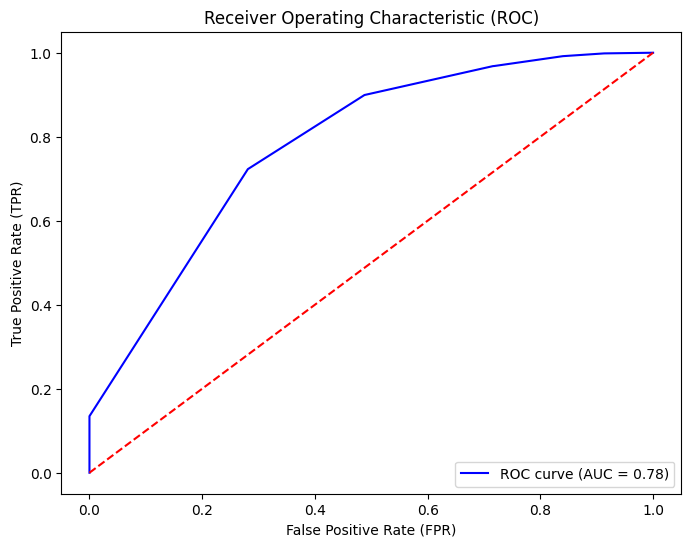

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de clasificación aleatoria
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

**INTERPRETACION**

Un AUC-ROC de 0.7823 indica que el modelo tiene una capacidad razonable para clasificar las instancias, con un buen balance en la identificación de ambas clases. Sin embargo, se recomienda un análisis adicional de otras métricas de rendimiento, como la precisión y el recall, para tener una visión más completa del comportamiento del modelo. La mejora continua del modelo podría llevar a un aumento en el rendimiento general y a una mayor efectividad en la clasificación de instancias.

#### Support Vector Classifiactor (SVC)

In [ ]:
svc_model = SVC(probability=True)
svc_model.fit(x_train, y_train)

SVC(probability=True)

Predicción

In [ ]:
y_pred = svc_model.predict(x_test)

Matriz de Confusión

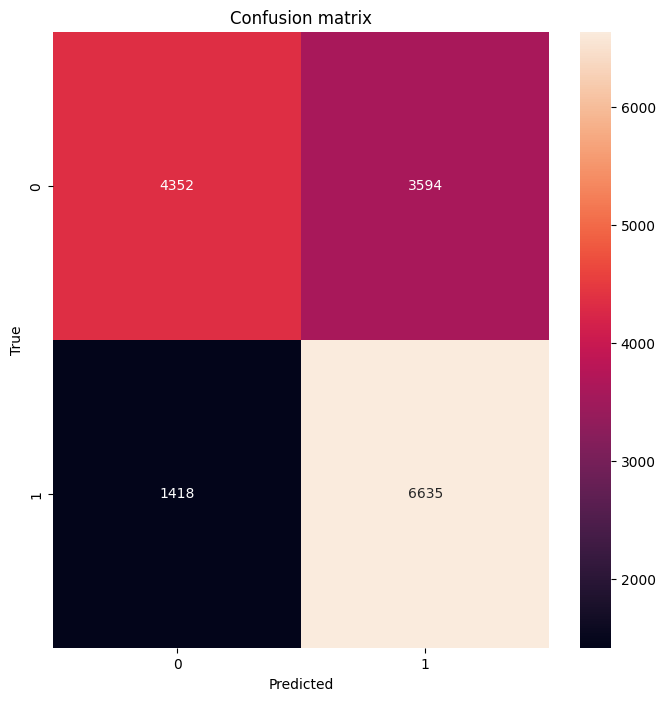

In [ ]:
LABELS = ["0","1"]

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",);
plt.title("Confusion matrix")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

Metricas

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.55      0.63      7946
           1       0.65      0.82      0.73      8053

    accuracy                           0.69     15999
   macro avg       0.70      0.69      0.68     15999
weighted avg       0.70      0.69      0.68     15999



**INTERPRETACION**

**Precision**

La precisión mide cuántos de los ejemplos predichos como positivos son realmente positivos. Para la clase 0, el modelo tiene una precisión de 0.75, lo que significa que el 75% de las instancias que fueron clasificadas como clase 0 son correctas. Esto indica que el modelo es bastante efectivo en la identificación de la clase 0. Sin embargo, la precisión para la clase 1 es más baja, con un valor de 0.65, lo que sugiere que el modelo está clasificando incorrectamente una proporción considerable de ejemplos de la clase 1 como clase 0.

**Recall**

El recall mide cuántos de los ejemplos positivos reales fueron predichos correctamente. Para la clase 0, el recall es de 0.55, lo que significa que solo el 55% de los ejemplos reales de la clase 0 fueron correctamente identificados por el modelo. Esto es relativamente bajo, lo que sugiere que el modelo tiene dificultades para detectar suficientes instancias de la clase 0. En contraste, para la clase 1, el recall es más alto, alcanzando 0.82. Esto indica que el modelo logra capturar el 82% de las instancias reales de la clase 1, lo que refleja un buen rendimiento en esta clase.

**F1-Score**

El F1-score es una métrica que equilibra la precisión y el recall. Para la clase 0, el F1-score es de 0.63, lo que sugiere un rendimiento moderado, indicando que hay un equilibrio aceptable entre precisión y recall, aunque todavía hay margen para mejorar. Por otro lado, para la clase 1, el F1-score es de 0.73, que es más alto, lo que indica que el modelo tiene un mejor equilibrio entre precisión y recall en esta clase, reflejando un desempeño razonablemente bueno.

**Accuracy**

La precisión global indica que el modelo predijo correctamente el 69% de las instancias en total. Aunque esto puede parecer un rendimiento aceptable, también sugiere que el modelo tiene problemas para generalizar adecuadamente, especialmente en la identificación de la clase 0. La diferencia en el rendimiento entre las dos clases pone de manifiesto que el modelo puede estar sesgado hacia la clase 1, lo que sugiere la necesidad de ajustar o mejorar el modelo para lograr un mejor equilibrio en la clasificación de ambas clases.

**Overfitting/Underfitting**

Interpretación: El modelo de Support Vector Classifier presenta métricas mixtas, con una precisión del 75% en la clase 0 y del 65% en la clase 1. Sin embargo, el recall es significativamente más bajo para la clase 0 (55%), lo que indica que el modelo tiene dificultades para identificar correctamente las instancias de esta clase. A pesar de un rendimiento razonablemente bueno en la clase 1 (recall del 82%), el bajo rendimiento en la clase 0 sugiere que el modelo está sufriendo de underfitting.

Curva ROC

In [ ]:
y_prob = svc_model.predict_proba(x_test)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc}")

AUC-ROC: 0.7670284056647239


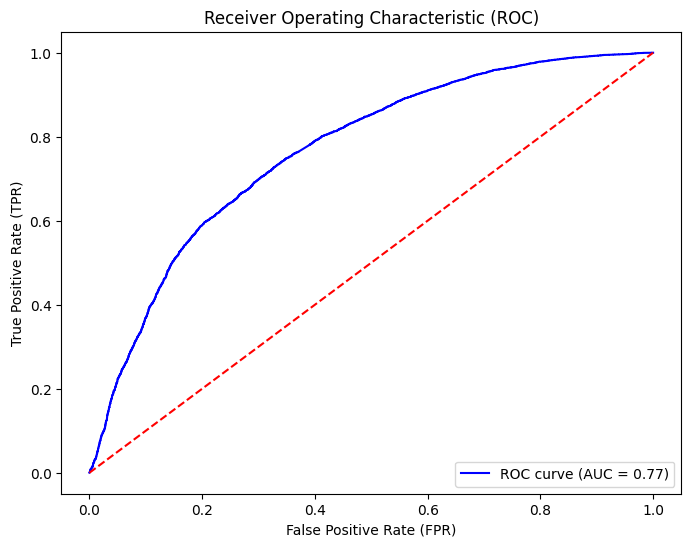

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de clasificación aleatoria
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

**INTERPRETACION**

Un AUC-ROC de 0.7670 indica que el modelo tiene una capacidad razonable para clasificar las instancias, mostrando un equilibrio en la identificación de las clases. Sin embargo, es recomendable realizar un análisis adicional de otras métricas, como precisión, recall y F1-score, para obtener una visión más completa del comportamiento del modelo. La mejora continua del modelo podría resultar en un aumento en el rendimiento y una mayor efectividad en la clasificación de instancias.

#### Regresion Logistica con hiperparametros

In [ ]:
rlModel = LogisticRegression(C=0.1, solver='lbfgs', max_iter=500, penalty='l2')
rlModel.fit(x_train, y_train)

LogisticRegression(C=0.1, max_iter=500)

In [ ]:
y_pred = rlModel.predict(x_test)

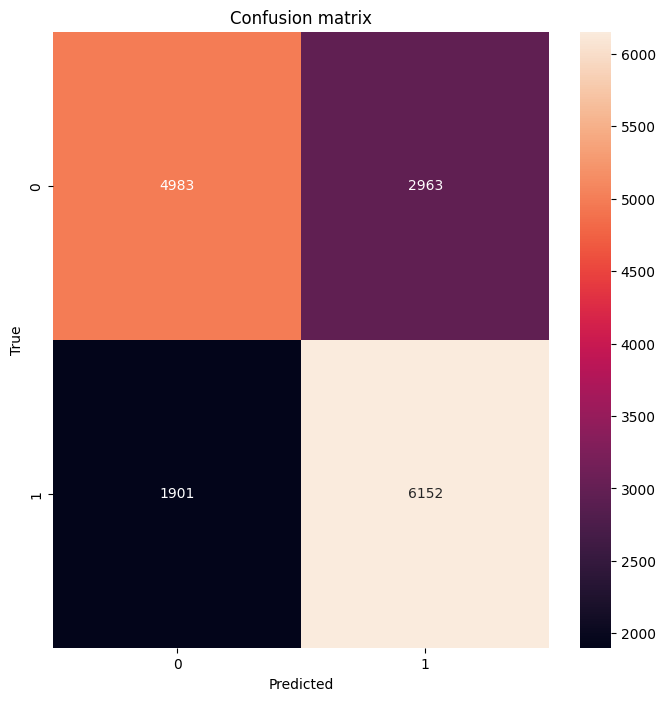

              precision    recall  f1-score   support

           0       0.72      0.63      0.67      7946
           1       0.67      0.76      0.72      8053

    accuracy                           0.70     15999
   macro avg       0.70      0.70      0.69     15999
weighted avg       0.70      0.70      0.69     15999



In [ ]:
LABELS = ["0","1"]

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",);
plt.title("Confusion matrix")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred))

**INTERPRETACION**

**Precision**

La precisión mide cuántos de los ejemplos predichos como positivos son realmente positivos. La clase 0 tiene una precisión de 0.72, lo que indica que el 72% de las instancias clasificadas como clase 0 son correctas. Para la clase 1, la precisión es ligeramente menor, 0.67, lo que refleja que aproximadamente el 67% de las instancias clasificadas como clase 1 son correctas. Ambas precisiones son relativamente cercanas, lo que sugiere un comportamiento equilibrado entre las dos clases.

**Recall**

El recall mide cuántos de los ejemplos positivos reales fueron predichos correctamente. La clase 0 tiene un recall de 0.63, lo que indica que el 63% de las instancias reales de la clase 0 fueron correctamente identificadas. Para la clase 1, el recall es mayor (0.76), lo que significa que el 76% de las instancias reales de la clase 1 fueron correctamente clasificadas. El modelo tiene mejor rendimiento en capturar ejemplos de la clase 1.

**F1-Score**

El F1-score es una métrica que equilibra la precisión y el recall. Para la clase 0, el F1-score es de 0.67, lo que refleja un balance razonable entre precisión y recall. Para la clase 1, el F1-score es más alto (0.72), lo que indica un mejor rendimiento en esta clase. El promedio ponderado de 0.70 muestra que el rendimiento general del modelo es aceptable, pero con margen de mejora, especialmente en la clase 0.

**Accuracy**

La precisión global del modelo es del 70%, lo que indica que el modelo predijo correctamente el 70% de las instancias en general. Esto sugiere un rendimiento razonable, aunque no sobresaliente, en términos de precisión global.

**Overfitting/Underfitting**

Interpretación: Similar al modelo anterior, pero con hiperparámetros ajustados, este modelo tiene métricas de rendimiento ligeramente mejores (con precisión de 72% en la clase 0 y 67% en la clase 1). Sin embargo, sigue siendo modesto y, dado que el rendimiento no mejora significativamente, sugiere que también está sufriendo de underfitting. Aunque se ajustan algunos hiperparámetros, puede que no sean suficientes para capturar las complejidades de los datos.

Curva ROC

In [ ]:
y_prob = rlModel.predict_proba(x_test)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc}")

AUC-ROC: 0.7624956754379157


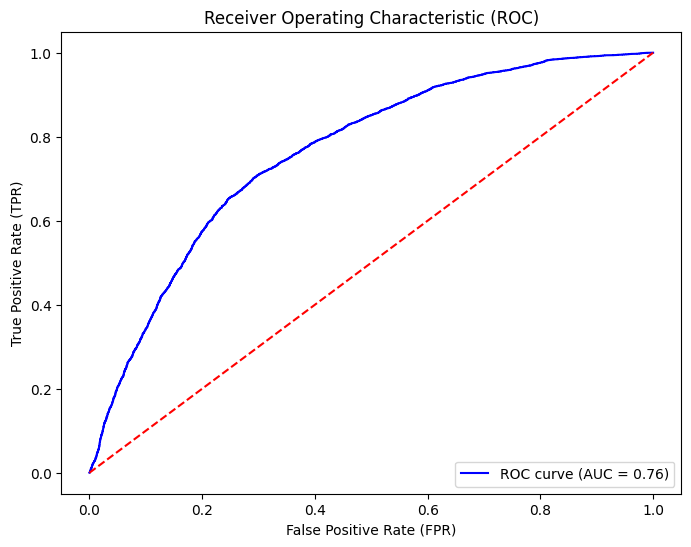

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de clasificación aleatoria
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

**INTERPRETACION**

Un AUC-ROC de 0.7625 indica que el modelo tiene una capacidad razonable para clasificar correctamente las instancias en sus respectivas clases. Sin embargo, es recomendable realizar un análisis complementario de otras métricas como precisión, recall y F1-score para obtener una visión más completa del rendimiento del modelo. Continuar mejorando y ajustando el modelo puede conducir a un aumento en su efectividad y a una mejor clasificación de instancias.

### 2.5 Evaluación de los modelos

| Modelo |Precisión (0)|	Precisión (1)|	Recall (0)|	Recall (1)|	F1-score (0)|	F1-score (1)|	Accuracy|	Support (0)|	Support (1)|
|----------|----------|----------|----------|----------|----------|----------|----------|----------|----------|
|RandomForestClassifier|0.91|	0.91|	0.91|	0.92|	0.91|	0.91|	0.91|	7946|	8053|
|Regresión Logística   |0.72|	0.68|	0.63|	0.76|	0.67|	0.72|	0.70|	7946|	8053|
|Árbol de Decisión sin (Hiperparam.)|0.86|	0.86|	0.85|	0.87|	0.86|	0.86|	0.86|	7946|	8053|
|Árbol de Decisión con (Hiperparam.)|0.72|	0.72|	0.72|	0.72|	0.72|	0.72|	0.72|	7946|	8053|
|Support Vector Classifier|0.75|	0.65|	0.55|	0.82|	0.63|	0.73|	0.69|	7946|	8053|
|Regresión Logística con (Hiperparam.)|0.72|	0.67|	0.63|	0.76|	0.67|	0.72|	0.70|	7946|	8053|

**Mejor Modelo: RandomForestClassifier**

El RandomForestClassifier es claramente el mejor modelo entre los seis evaluados, por las siguientes razones:

**Precisión alta en ambas clases:** Con una precisión de 0.91 tanto para la clase 0 como para la clase 1, predice correctamente una gran proporción de ambos tipos de casos.

**Balance en recall y F1-score:** Los valores de recall y F1-score son consistentemente altos (0.91 para ambas clases), indicando que no solo tiene buenas predicciones, sino también un equilibrio favorable entre falsos positivos y falsos negativos.

**Accuracy:** Con una precisión del 91%, el modelo tiene el mayor porcentaje de predicciones correctas en general, lo que resalta su eficacia.

**Soporte en datos balanceado:** Dado que el soporte es bastante equilibrado en este conjunto de datos, el rendimiento del modelo se mantiene robusto en ambas clases.



---



**Peor Modelo: Support Vector Classifier (SVC)**

El Support Vector Classifier (SVC) es el modelo con el peor rendimiento en esta comparativa, por las siguientes razones:

**Desbalance significativo en precisión:** Aunque tiene una precisión razonable para la clase 0 (0.75), su precisión para la clase 1 es baja (0.65). Esto implica que predice incorrectamente muchos de los casos de la clase 1.

**Recall desequilibrado:** Mientras que el recall para la clase 1 es aceptable (0.82), el recall para la clase 0 es mucho más bajo (0.55), indicando que pierde muchos casos de la clase 0.

**F1-score bajo:** El F1-score es de 0.63 para la clase 0 y 0.73 para la clase 1, lo que muestra un desbalance entre los falsos positivos y negativos. Aunque el F1-score para la clase 1 es más alto, el de la clase 0 es inferior.

**Accuracy global bajo (69%):** Con un accuracy del 69%, este modelo predice incorrectamente en una parte considerable de los casos, lo que indica un rendimiento global muy inferior en comparación con otros modelos.

## <font color='teal'>3. Conclusiones</font>

De los modelos de regresión y clasificación evaluados, RandomForestClassifier demostró ser el más eficaz, alcanzando un 91% de precisión y un buen balance entre clases, lo que refleja su capacidad para capturar la complejidad de los datos. Los Árboles de Decisión mostraron un rendimiento aceptable, pero inferior, mientras que la Regresión Logística es útil para problemas más simples, con un 70% de precisión. En contraste, el Support Vector Classifier (SVC) fue el peor modelo, con un notable desequilibrio en sus predicciones y solo un 69% de accuracy. Los modelos de Regresión Lineal, Polinomial y SVR tampoco fueron adecuados debido a sus altos errores y baja capacidad explicativa. En general, los datos presentan una complejidad que solo los modelos avanzados, como el RandomForest, pueden manejar eficazmente, sugiriendo la presencia de patrones no lineales en el conjunto de datos.